# 5-Spin Cell Structure

In [32]:
# ============================================================
# 5-spin cell, 2-cell cluster Niemeyer-van Leeuwen
# Drop-in companion to your 3-spin code.
# Imports logsumexp and build_J from your existing utils.py
# ============================================================

import numpy as np
from numba import njit
from itertools import product
import matplotlib.pyplot as plt

# Reuse your existing utilities
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'lib')))
from utils import logsumexp, build_J

# ---- Cell geometry constants (5-spin contiguous) ----
__cell_geometry__ = "contiguous_5spin"
CELL_SIZE = 5
B = 5  # length-rescaling factor

# All 2^5 = 32 spin configurations
_all_spins5 = np.array(list(product([-1, 1], repeat=CELL_SIZE)), dtype=np.int64)
plus_configs5  = _all_spins5[np.sum(_all_spins5, axis=1) >=  1]   # 16 configs
minus_configs5 = _all_spins5[np.sum(_all_spins5, axis=1) <= -1]   # 16 configs

# ---- Distance / scale bookkeeping ----
@njit(cache=True)
def required_initial_max_distance_5(max_dist_final, n_steps):
    """Inverse of r_max: how big D_0 must be to support n_steps with final D = max_dist_final."""
    D = max_dist_final
    for _ in range(n_steps):
        D = B * D + (CELL_SIZE - 1)   # 5*D + 4
    return D

@njit(cache=True)
def r_max_5(D):
    """Largest renormalized r' available given current J array length D+1."""
    return (D - (CELL_SIZE - 1)) // B   # (D - 4) // 5

@njit(cache=True)
def determine_r_max_5(D):
    return r_max_5(D)

# ---- Intracell energy: 10 pairs per cell ----
@njit(cache=True)
def intracell_energies_5(spins, J):
    """
    spins: (n, 5) array of +/-1
    Returns array of intracell energies, summing J[|i-j|] * s_i * s_j over all 10 pairs.
    """
    n = spins.shape[0]
    D = len(J) - 1
    E = np.empty(n, dtype=np.float64)
    for k in range(n):
        e = 0.0
        for i in range(CELL_SIZE):
            for j in range(i + 1, CELL_SIZE):
                d = j - i  # distances 1..4
                if d <= D:
                    e += J[d] * spins[k, i] * spins[k, j]
        E[k] = e
    return E

# ---- log R(++), R(+-) for renormalized J at separation r ----
@njit(cache=True)
def log_Rpp_Rpm_5(r, J):
    """
    r: renormalized separation (cells are b*r physical sites apart, center-to-center;
       contiguously stacked, so right cell starts at position 1 + 5*r).
    """
    D = len(J) - 1
    E_plus  = intracell_energies_5(plus_configs5,  J)
    E_minus = intracell_energies_5(minus_configs5, J)

    # Physical positions
    left_pos  = np.array([1, 2, 3, 4, 5], dtype=np.int64)
    # For r=1, right cell occupies [6,7,8,9,10]; for r=2, [11..15], etc.
    right_pos = np.empty(CELL_SIZE, dtype=np.int64)
    for k in range(CELL_SIZE):
        right_pos[k] = 6 + k + CELL_SIZE * (r - 1)

    # 5x5 distance matrix
    distances = np.empty((CELL_SIZE, CELL_SIZE), dtype=np.int64)
    for a in range(CELL_SIZE):
        for b_ in range(CELL_SIZE):
            distances[a, b_] = abs(right_pos[b_] - left_pos[a])

    n_plus  = plus_configs5.shape[0]
    n_minus = minus_configs5.shape[0]

    # ---- R(++) ----
    totals_pp = np.empty(n_plus * n_plus, dtype=np.float64)
    idx = 0
    for iL in range(n_plus):
        sL = plus_configs5[iL]
        EL = E_plus[iL]
        for iR in range(n_plus):
            sR = plus_configs5[iR]
            ER = E_plus[iR]
            E_int = 0.0
            for a in range(CELL_SIZE):
                for b_ in range(CELL_SIZE):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_pp[idx] = EL + ER + E_int
            idx += 1

    # ---- R(+-) ----
    totals_pm = np.empty(n_plus * n_minus, dtype=np.float64)
    idx = 0
    for iL in range(n_plus):
        sL = plus_configs5[iL]
        EL = E_plus[iL]
        for iR in range(n_minus):
            sR = minus_configs5[iR]
            ER = E_minus[iR]
            E_int = 0.0
            for a in range(CELL_SIZE):
                for b_ in range(CELL_SIZE):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_pm[idx] = EL + ER + E_int
            idx += 1

    log_pp = logsumexp(totals_pp)
    log_pm = logsumexp(totals_pm)
    return log_pp, log_pm

# ---- log R(++), R(--) at nonzero H, used for field recursion (r=1) ----
@njit(cache=True)
def log_Rpp_Rmm_nonzero_H_5(J, H):
    E_plus  = intracell_energies_5(plus_configs5,  J)
    E_minus = intracell_energies_5(minus_configs5, J)

    left_pos  = np.array([1, 2, 3, 4, 5], dtype=np.int64)
    right_pos = np.array([6, 7, 8, 9, 10], dtype=np.int64)

    distances = np.empty((CELL_SIZE, CELL_SIZE), dtype=np.int64)
    for a in range(CELL_SIZE):
        for b_ in range(CELL_SIZE):
            distances[a, b_] = abs(right_pos[b_] - left_pos[a])

    D = len(J) - 1
    n_plus  = plus_configs5.shape[0]
    n_minus = minus_configs5.shape[0]

    # R(++)
    totals_pp = np.empty(n_plus * n_plus, dtype=np.float64)
    idx = 0
    for iL in range(n_plus):
        sL = plus_configs5[iL]
        EL = E_plus[iL]
        magL = sL[0] + sL[1] + sL[2] + sL[3] + sL[4]
        for iR in range(n_plus):
            sR = plus_configs5[iR]
            ER = E_plus[iR]
            magR = sR[0] + sR[1] + sR[2] + sR[3] + sR[4]
            E_int = 0.0
            for a in range(CELL_SIZE):
                for b_ in range(CELL_SIZE):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_pp[idx] = EL + ER + E_int + H * (magL + magR)
            idx += 1

    # R(--)
    totals_mm = np.empty(n_minus * n_minus, dtype=np.float64)
    idx = 0
    for iL in range(n_minus):
        sL = minus_configs5[iL]
        EL = E_minus[iL]
        magL = sL[0] + sL[1] + sL[2] + sL[3] + sL[4]
        for iR in range(n_minus):
            sR = minus_configs5[iR]
            ER = E_minus[iR]
            magR = sR[0] + sR[1] + sR[2] + sR[3] + sR[4]
            E_int = 0.0
            for a in range(CELL_SIZE):
                for b_ in range(CELL_SIZE):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_mm[idx] = EL + ER + E_int + H * (magL + magR)
            idx += 1

    log_pp = logsumexp(totals_pp)
    log_mm = logsumexp(totals_mm)
    return log_pp, log_mm

# ---- RG step ----
@njit(cache=True)
def rg_step_5(J, a=None):
    D = len(J) - 1
    rmax = determine_r_max_5(D)

    J_new = np.zeros_like(J)
    J_new[0] = 0.0

    # Head: exact (cluster) renormalization
    for r in range(1, rmax + 1):
        log_R_pp, log_R_pm = log_Rpp_Rpm_5(r, J)
        J_new[r] = 0.5 * (log_R_pp - log_R_pm)

    # Tail: power-law continuation if exponent provided
    if a is not None:
        anchor = J_new[rmax]
        for r in range(rmax + 1, D + 1):
            J_new[r] = anchor * (rmax / r) ** a

    return J_new

@njit(cache=True)
def renormalized_field_5(J, H):
    log_pp, log_mm = log_Rpp_Rmm_nonzero_H_5(J, H)
    return 0.25 * (log_pp - log_mm)

# ---- Critical coupling search (bisection on J0) ----
def find_Jc_5(a, Jlow=1e-2, Jhigh=1e2, max_steps=6, max_dist_final=9,
              tol=1e-5, growth_threshold=1e3, decay_threshold=1e-3):
    def grows(J0):
        D0 = required_initial_max_distance_5(max_dist_final, max_steps)
        J = build_J(J0, a, D0)
        r = 5
        Jr_initial = abs(J[r])
        for _ in range(max_steps):
            if abs(J[r]) > growth_threshold:
                return True
            if abs(J[r]) < decay_threshold:
                return False
            J = rg_step_5(J)
        return abs(J[r]) > Jr_initial

    while (Jhigh - Jlow) > tol:
        Jmid = 0.5 * (Jlow + Jhigh)
        if grows(Jmid):
            Jhigh = Jmid
        else:
            Jlow = Jmid
    return 0.5 * (Jlow + Jhigh)

# ============================================================
# Flow visualization (mirrors your existing notebook code)
# ============================================================

def generate_rg_flow_5(J0, a, max_dist_final, n_steps):
    D0 = required_initial_max_distance_5(max_dist_final, n_steps)
    J = build_J(J0, a, D0)
    J_list = [J.copy()]
    for step in range(n_steps):
        J = rg_step_5(J)
        J_list.append(J.copy())
    return J_list

def extract_flows_5(J_list, max_dist_final):
    n_rec = len(J_list)
    flows = np.zeros((n_rec, max_dist_final + 1), dtype=float)
    for step, J in enumerate(J_list):
        D_curr = len(J) - 1
        r_keep = min(max_dist_final, D_curr)
        flows[step, :r_keep + 1] = J[:r_keep + 1]
    return flows

def plot_rg_flow_5(flows, distances_to_plot=None, fig_name=None):
    n_rec, _ = flows.shape
    max_dist = flows.shape[1] - 1
    steps = np.arange(n_rec)
    if distances_to_plot is None:
        distances_to_plot = range(1, max_dist + 1)
    plt.figure(figsize=(7, 5))
    for r in distances_to_plot:
        if 1 <= r <= max_dist:
            plt.plot(steps, flows[:, r], marker='o', label=f"${r}$")
    plt.xlim(0, None)
    plt.xlabel(r"RG iteration number $k$", fontsize=14)
    plt.ylabel(r"Interaction $J_r$", fontsize=14)
    plt.legend(title="$r$", title_fontsize=12)
    plt.tight_layout()
    if fig_name:
        plt.savefig(fig_name)
    plt.show()

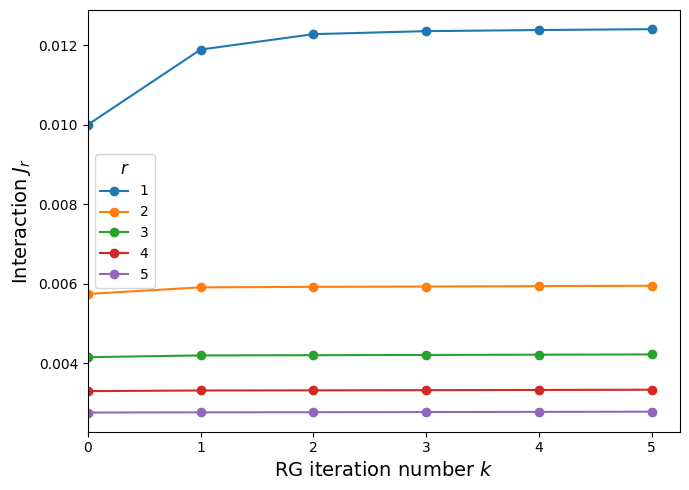

In [19]:
T = 100
J0 = 1.0 / T
a = 0.8
max_dist_final = 9
n_steps = 5

J_list = generate_rg_flow_5(J0, a, max_dist_final, n_steps)
flows = extract_flows_5(J_list, max_dist_final)
plot_rg_flow_5(flows, distances_to_plot=[1, 2, 3, 4, 5])

a = 0.7000  →  Jc = 0.00308, Tc = 3.24e+02
a = 0.8643  →  Jc = 0.0424, Tc = 23.6
a = 1.0286  →  Jc = 0.123, Tc = 8.11
a = 1.1929  →  Jc = 0.205, Tc = 4.88
a = 1.3571  →  Jc = 0.292, Tc = 3.42
a = 1.5214  →  Jc = 0.392, Tc = 2.55
a = 1.6857  →  Jc = 0.513, Tc = 1.95
a = 1.8500  →  Jc = 0.687, Tc = 1.46
a = 2.0143  →  Jc = 1e+03, Tc = 0.001
a = 2.1786  →  Jc = 1e+03, Tc = 0.001
a = 2.3429  →  Jc = 1e+03, Tc = 0.001
a = 2.5071  →  Jc = 1e+03, Tc = 0.001
a = 2.6714  →  Jc = 1e+03, Tc = 0.001
a = 2.8357  →  Jc = 1e+03, Tc = 0.001
a = 3.0000  →  Jc = 1e+03, Tc = 0.001


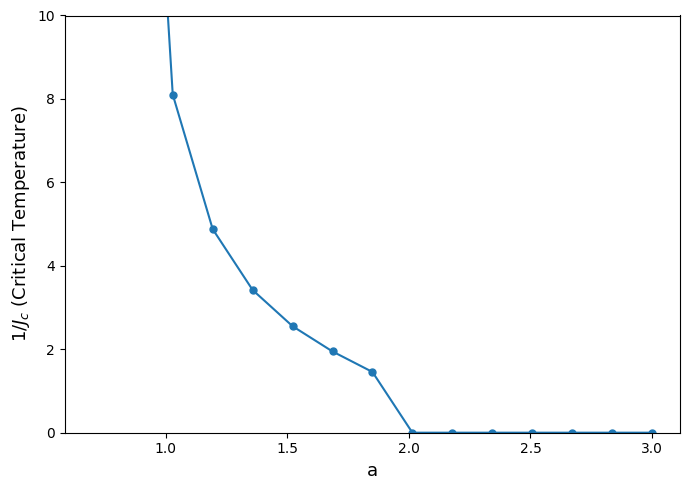

In [33]:
# ============================================================
# Critical line: 5-spin cell version
# Mirrors the 3-spin scan for direct comparison
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# These come from the 5-spin module/notebook cell defined earlier
# from your_5spin_module import find_Jc_5

a_vals = np.linspace(0.7, 3, 15)
Jc_vals_5 = []
Tc_vals_5 = []

for a in a_vals:
    Jc = find_Jc_5(
        a=a,
        Jlow=1e-3, Jhigh=1e3,
        max_steps=5, max_dist_final=9,
        tol=1e-5,
        growth_threshold=1e3, decay_threshold=1e-3
    )
    Jc_vals_5.append(Jc)
    Tc_vals_5.append(1.0 / Jc)
    print(f"a = {a:.4f}  →  Jc = {Jc:.3}, Tc = {1/Jc:.3}")

Jc_vals_5 = np.array(Jc_vals_5)
Tc_vals_5 = np.array(Tc_vals_5)

plt.figure(figsize=(7, 5))
plt.plot(a_vals, Tc_vals_5, 'o-', ms=5, label="5-spin cell")
plt.ylim(0, 10)
plt.xlabel("a", fontsize=13)
plt.ylabel(r"$1/J_c$ (Critical Temperature)", fontsize=13)
plt.grid(False)
plt.tight_layout()
plt.show()

In [21]:
ipek = np.array([[0.7500,4.52125199],
[0.8000,3.60338191],
[0.9000,2.57710587],
[1.0000,2.01262302],
[1.1000,1.65082931],
[1.2000,1.39555058],
[1.3000,1.20307433],
[1.4000,1.05067106],
[1.5000,0.92526929],
[1.6000,0.81868463],
[1.7000,0.72532446],
[1.8000,0.64086121],
[1.8500,0.60067639],
[1.9000,0.56101569],
[1.9500,0.52090090],
[1.9800,0.49592122],
[2.0000,0.47848769],
[2.0200,0.46001853],
[2.0500,0.42884849],
[2.1000,0.34607338]])

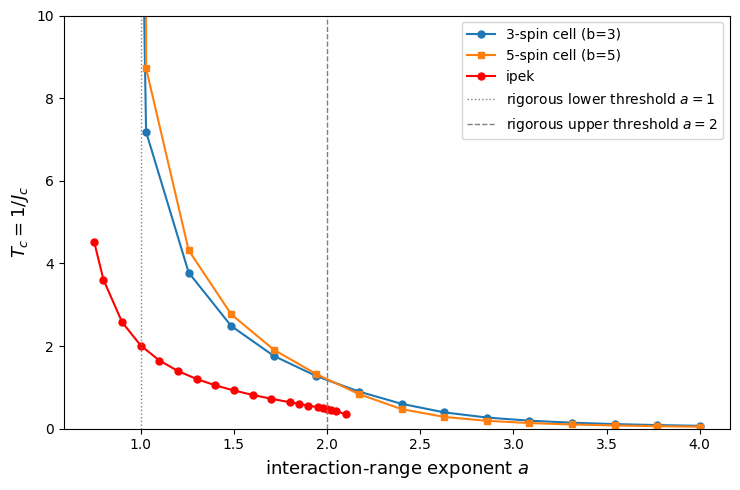

In [28]:
plt.figure(figsize=(7.5, 5))
plt.plot(a_vals, Tc_3, 'o-', ms=5, label="3-spin cell (b=3)")
plt.plot(a_vals, Tc_5, 's-', ms=5, label="5-spin cell (b=5)")
plt.plot(ipek[::,0], ipek[::,1], 'ro-', ms=5, label="ipek")
plt.axvline(1.0, color='gray', ls=':', lw=1, label="rigorous lower threshold $a=1$")
plt.axvline(2.0, color='gray', ls='--', lw=1, label="rigorous upper threshold $a=2$")
plt.ylim(0, 10)
plt.xlabel(r"interaction-range exponent $a$", fontsize=13)
plt.ylabel(r"$T_c = 1/J_c$", fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

a = 0.800   3-spin Tc =  70.5030   5-spin Tc = 996.2885
a = 1.029   3-spin Tc =   7.1848   5-spin Tc =   8.7235
a = 1.257   3-spin Tc =   3.7788   5-spin Tc =   4.3179
a = 1.486   3-spin Tc =   2.4847   5-spin Tc =   2.7674
a = 1.714   3-spin Tc =   1.7617   5-spin Tc =   1.9117
a = 1.943   3-spin Tc =   1.2723   5-spin Tc =   1.3199
a = 2.171   3-spin Tc =   0.8986   5-spin Tc =   0.8374
a = 2.400   3-spin Tc =   0.6028   5-spin Tc =   0.4739
a = 2.629   3-spin Tc =   0.3959   5-spin Tc =   0.2859
a = 2.857   3-spin Tc =   0.2707   5-spin Tc =   0.1913
a = 3.086   3-spin Tc =   0.1947   5-spin Tc =   0.1369
a = 3.314   3-spin Tc =   0.1456   5-spin Tc =   0.1023
a = 3.543   3-spin Tc =   0.1119   5-spin Tc =   0.0786
a = 3.771   3-spin Tc =   0.0878   5-spin Tc =   0.0617
a = 4.000   3-spin Tc =   0.0700   5-spin Tc =   0.0492


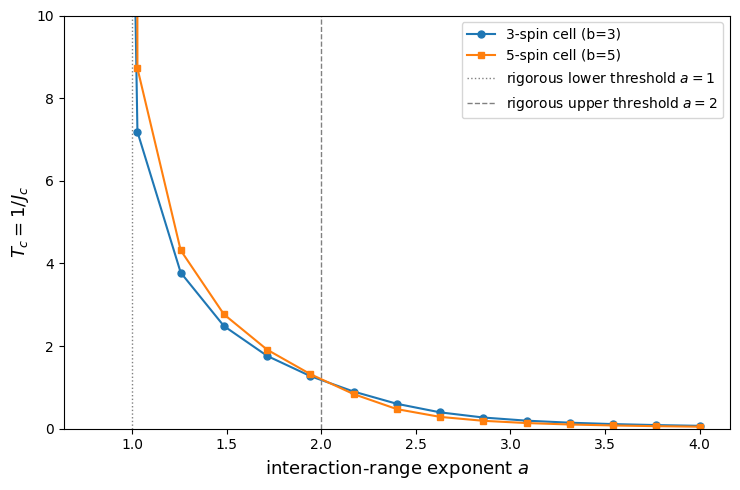

In [27]:
# ============================================================
# Side-by-side: 3-spin vs 5-spin critical lines
# ============================================================

from renormalization import find_Jc                  # your 3-spin

a_vals = np.linspace(0.8, 4, 15)

Jc_3, Tc_3 = [], []
Jc_5, Tc_5 = [], []

for a in a_vals:
    jc3 = find_Jc(
        a=a, Jlow=1e-3, Jhigh=1e3,
        max_steps=5, max_dist_final=20,
        tol=1e-5, growth_threshold=1e3, decay_threshold=1e-3
    )
    jc5 = find_Jc_5(
        a=a, Jlow=1e-3, Jhigh=1e3,
        max_steps=5, max_dist_final=20,
        tol=1e-5, growth_threshold=1e3, decay_threshold=1e-3
    )
    Jc_3.append(jc3); Tc_3.append(1.0 / jc3)
    Jc_5.append(jc5); Tc_5.append(1.0 / jc5)
    print(f"a = {a:.3f}   3-spin Tc = {1/jc3:8.4f}   5-spin Tc = {1/jc5:8.4f}")

Tc_3 = np.array(Tc_3)
Tc_5 = np.array(Tc_5)

plt.figure(figsize=(7.5, 5))
plt.plot(a_vals, Tc_3, 'o-', ms=5, label="3-spin cell (b=3)")
plt.plot(a_vals, Tc_5, 's-', ms=5, label="5-spin cell (b=5)")
plt.plot(ipek[::,0], ipek[::,1], 'ro-', ms=5, label="ipek")
plt.axvline(1.0, color='gray', ls=':', lw=1, label="rigorous lower threshold $a=1$")
plt.axvline(2.0, color='gray', ls='--', lw=1, label="rigorous upper threshold $a=2$")
plt.ylim(0, 10)
plt.xlabel(r"interaction-range exponent $a$", fontsize=13)
plt.ylabel(r"$T_c = 1/J_c$", fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 10-Spin Cell Structure

In [29]:
# ============================================================
# 10-spin cell, 2-cell cluster Niemeyer-van Leeuwen
# Random tie-breaking convention for sum=0 configurations.
#
# WARNING: Per-RG-step cost is ~500x the 5-spin version.
# Expect minutes per find_Jc_10 call, hours for a full critical line.
# ============================================================

import numpy as np
from numba import njit
from itertools import product
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'lib')))
from utils import logsumexp, build_J

# ---- Cell geometry ----
__cell_geometry__ = "contiguous_10spin"
CELL_SIZE_10 = 10
B_10 = 10

# All 2^10 = 1024 configs
_all_spins10 = np.array(list(product([-1, 1], repeat=CELL_SIZE_10)), dtype=np.int64)
_sums10 = np.sum(_all_spins10, axis=1)

# Plus sector: sum >= 1 (386 configs)
# Minus sector: sum <= -1 (386 configs)
# Tied (sum == 0): 252 configs, each contributes weight 1/2 to plus AND 1/2 to minus
plus_strict10  = _all_spins10[_sums10 >=  1]
minus_strict10 = _all_spins10[_sums10 <= -1]
tied10         = _all_spins10[_sums10 ==  0]

# Tie-breaking weights: in log-space, ln(1/2) = -ln(2)
_LN_HALF = -np.log(2.0)

# Concatenate strict + tied for each sector; carry per-config log-weight
plus_configs10  = np.concatenate([plus_strict10,  tied10], axis=0)
minus_configs10 = np.concatenate([minus_strict10, tied10], axis=0)

plus_log_weights10 = np.concatenate([
    np.zeros(plus_strict10.shape[0],  dtype=np.float64),       # weight 1
    np.full (tied10.shape[0],         _LN_HALF, dtype=np.float64)   # weight 1/2
])
minus_log_weights10 = np.concatenate([
    np.zeros(minus_strict10.shape[0], dtype=np.float64),
    np.full (tied10.shape[0],         _LN_HALF, dtype=np.float64)
])

# ---- Distance / scale bookkeeping ----
@njit(cache=True)
def required_initial_max_distance_10(max_dist_final, n_steps):
    D = max_dist_final
    for _ in range(n_steps):
        D = B_10 * D + (CELL_SIZE_10 - 1)   # 10*D + 9
    return D

@njit(cache=True)
def r_max_10(D):
    return (D - (CELL_SIZE_10 - 1)) // B_10

@njit(cache=True)
def determine_r_max_10(D):
    return r_max_10(D)

# ---- Intracell energy: 45 pairs ----
@njit(cache=True)
def intracell_energies_10(spins, J):
    n = spins.shape[0]
    D = len(J) - 1
    E = np.empty(n, dtype=np.float64)
    for k in range(n):
        e = 0.0
        for i in range(CELL_SIZE_10):
            for j in range(i + 1, CELL_SIZE_10):
                d = j - i
                if d <= D:
                    e += J[d] * spins[k, i] * spins[k, j]
        E[k] = e
    return E

# ---- log R(++), R(+-) at separation r ----
@njit(cache=True)
def log_Rpp_Rpm_10(r, J,
                   plus_cfg, minus_cfg,
                   plus_lw, minus_lw):
    D = len(J) - 1
    E_plus  = intracell_energies_10(plus_cfg,  J)
    E_minus = intracell_energies_10(minus_cfg, J)

    left_pos  = np.empty(CELL_SIZE_10, dtype=np.int64)
    right_pos = np.empty(CELL_SIZE_10, dtype=np.int64)
    for k in range(CELL_SIZE_10):
        left_pos[k]  = 1 + k
        right_pos[k] = 1 + CELL_SIZE_10 + k + CELL_SIZE_10 * (r - 1)

    distances = np.empty((CELL_SIZE_10, CELL_SIZE_10), dtype=np.int64)
    for a in range(CELL_SIZE_10):
        for b_ in range(CELL_SIZE_10):
            distances[a, b_] = abs(right_pos[b_] - left_pos[a])

    n_plus  = plus_cfg.shape[0]
    n_minus = minus_cfg.shape[0]

    # R(++)
    totals_pp = np.empty(n_plus * n_plus, dtype=np.float64)
    idx = 0
    for iL in range(n_plus):
        sL = plus_cfg[iL]
        EL = E_plus[iL]
        wL = plus_lw[iL]
        for iR in range(n_plus):
            sR = plus_cfg[iR]
            ER = E_plus[iR]
            wR = plus_lw[iR]
            E_int = 0.0
            for a in range(CELL_SIZE_10):
                for b_ in range(CELL_SIZE_10):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_pp[idx] = EL + ER + E_int + wL + wR
            idx += 1

    # R(+-)
    totals_pm = np.empty(n_plus * n_minus, dtype=np.float64)
    idx = 0
    for iL in range(n_plus):
        sL = plus_cfg[iL]
        EL = E_plus[iL]
        wL = plus_lw[iL]
        for iR in range(n_minus):
            sR = minus_cfg[iR]
            ER = E_minus[iR]
            wR = minus_lw[iR]
            E_int = 0.0
            for a in range(CELL_SIZE_10):
                for b_ in range(CELL_SIZE_10):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_pm[idx] = EL + ER + E_int + wL + wR
            idx += 1

    log_pp = logsumexp(totals_pp)
    log_pm = logsumexp(totals_pm)
    return log_pp, log_pm

# ---- log R(++), R(--) at nonzero H ----
@njit(cache=True)
def log_Rpp_Rmm_nonzero_H_10(J, H,
                             plus_cfg, minus_cfg,
                             plus_lw, minus_lw):
    E_plus  = intracell_energies_10(plus_cfg,  J)
    E_minus = intracell_energies_10(minus_cfg, J)

    left_pos  = np.empty(CELL_SIZE_10, dtype=np.int64)
    right_pos = np.empty(CELL_SIZE_10, dtype=np.int64)
    for k in range(CELL_SIZE_10):
        left_pos[k]  = 1 + k
        right_pos[k] = 1 + CELL_SIZE_10 + k

    distances = np.empty((CELL_SIZE_10, CELL_SIZE_10), dtype=np.int64)
    for a in range(CELL_SIZE_10):
        for b_ in range(CELL_SIZE_10):
            distances[a, b_] = abs(right_pos[b_] - left_pos[a])

    D = len(J) - 1
    n_plus  = plus_cfg.shape[0]
    n_minus = minus_cfg.shape[0]

    # R(++)
    totals_pp = np.empty(n_plus * n_plus, dtype=np.float64)
    idx = 0
    for iL in range(n_plus):
        sL = plus_cfg[iL]
        EL = E_plus[iL]
        wL = plus_lw[iL]
        magL = 0
        for k in range(CELL_SIZE_10):
            magL += sL[k]
        for iR in range(n_plus):
            sR = plus_cfg[iR]
            ER = E_plus[iR]
            wR = plus_lw[iR]
            magR = 0
            for k in range(CELL_SIZE_10):
                magR += sR[k]
            E_int = 0.0
            for a in range(CELL_SIZE_10):
                for b_ in range(CELL_SIZE_10):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_pp[idx] = EL + ER + E_int + wL + wR + H * (magL + magR)
            idx += 1

    # R(--)
    totals_mm = np.empty(n_minus * n_minus, dtype=np.float64)
    idx = 0
    for iL in range(n_minus):
        sL = minus_cfg[iL]
        EL = E_minus[iL]
        wL = minus_lw[iL]
        magL = 0
        for k in range(CELL_SIZE_10):
            magL += sL[k]
        for iR in range(n_minus):
            sR = minus_cfg[iR]
            ER = E_minus[iR]
            wR = minus_lw[iR]
            magR = 0
            for k in range(CELL_SIZE_10):
                magR += sR[k]
            E_int = 0.0
            for a in range(CELL_SIZE_10):
                for b_ in range(CELL_SIZE_10):
                    d = distances[a, b_]
                    if d <= D:
                        E_int += J[d] * sL[a] * sR[b_]
            totals_mm[idx] = EL + ER + E_int + wL + wR + H * (magL + magR)
            idx += 1

    log_pp = logsumexp(totals_pp)
    log_mm = logsumexp(totals_mm)
    return log_pp, log_mm

# ---- RG step ----
@njit(cache=True)
def rg_step_10(J, plus_cfg, minus_cfg, plus_lw, minus_lw, a=None):
    D = len(J) - 1
    rmax = determine_r_max_10(D)

    J_new = np.zeros_like(J)
    for r in range(1, rmax + 1):
        log_R_pp, log_R_pm = log_Rpp_Rpm_10(r, J, plus_cfg, minus_cfg, plus_lw, minus_lw)
        J_new[r] = 0.5 * (log_R_pp - log_R_pm)

    if a is not None:
        anchor = J_new[rmax]
        for r in range(rmax + 1, D + 1):
            J_new[r] = anchor * (rmax / r) ** a

    return J_new

# Convenience wrapper that hides the config arrays
def rg_step_10_wrap(J, a=None):
    return rg_step_10(J, plus_configs10, minus_configs10,
                         plus_log_weights10, minus_log_weights10, a=a)

def renormalized_field_10(J, H):
    log_pp, log_mm = log_Rpp_Rmm_nonzero_H_10(
        J, H, plus_configs10, minus_configs10,
        plus_log_weights10, minus_log_weights10
    )
    return 0.25 * (log_pp - log_mm)

# ---- Critical coupling search ----
def find_Jc_10(a, Jlow=1e-2, Jhigh=1e2, max_steps=6, max_dist_final=9,
               tol=1e-5, growth_threshold=1e3, decay_threshold=1e-3):
    def grows(J0):
        D0 = required_initial_max_distance_10(max_dist_final, max_steps)
        J = build_J(J0, a, D0)
        J1_initial = abs(J[1])
        for _ in range(max_steps):
            if abs(J[1]) > growth_threshold:
                return True
            if abs(J[1]) < decay_threshold:
                return False
            J = rg_step_10_wrap(J)
        return abs(J[1]) > J1_initial

    while (Jhigh - Jlow) > tol:
        Jmid = 0.5 * (Jlow + Jhigh)
        if grows(Jmid):
            Jhigh = Jmid
        else:
            Jlow = Jmid
    return 0.5 * (Jlow + Jhigh)

# ---- Flow visualization ----
def generate_rg_flow_10(J0, a, max_dist_final, n_steps):
    D0 = required_initial_max_distance_10(max_dist_final, n_steps)
    J = build_J(J0, a, D0)
    J_list = [J.copy()]
    for _ in range(n_steps):
        J = rg_step_10_wrap(J)
        J_list.append(J.copy())
    return J_list

def extract_flows_10(J_list, max_dist_final):
    n_rec = len(J_list)
    flows = np.zeros((n_rec, max_dist_final + 1), dtype=float)
    for step, J in enumerate(J_list):
        D_curr = len(J) - 1
        r_keep = min(max_dist_final, D_curr)
        flows[step, :r_keep + 1] = J[:r_keep + 1]
    return flows

def plot_rg_flow_10(flows, distances_to_plot=None, fig_name=None):
    n_rec, _ = flows.shape
    max_dist = flows.shape[1] - 1
    steps = np.arange(n_rec)
    if distances_to_plot is None:
        distances_to_plot = range(1, max_dist + 1)
    plt.figure(figsize=(7, 5))
    for r in distances_to_plot:
        if 1 <= r <= max_dist:
            plt.plot(steps, flows[:, r], marker='o', label=f"${r}$")
    plt.xlim(0, None)
    plt.xlabel(r"RG iteration number $k$", fontsize=14)
    plt.ylabel(r"Interaction $J_r$", fontsize=14)
    plt.legend(title="$r$", title_fontsize=12)
    plt.tight_layout()
    if fig_name:
        plt.savefig(fig_name)
    plt.show()

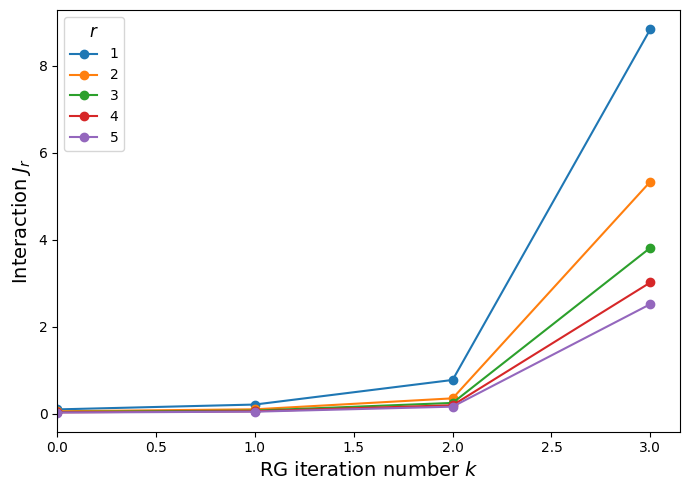

In [31]:
T = 10
J0 = 1.0 / T
a = 0.9
max_dist_final = 20
n_steps = 3

J_list = generate_rg_flow_10(J0, a, max_dist_final, n_steps)
flows = extract_flows_10(J_list, max_dist_final)
plot_rg_flow_10(flows, distances_to_plot=[1, 2, 3, 4, 5])

In [ ]:
# ============================================================
# Three-way comparison: 3-spin, 5-spin, 10-spin critical lines
# ============================================================

import time

a_vals = np.linspace(0.8, 3, 10)   # keep small for 10-spin

results = {3: {"Jc": [], "Tc": []},
           5: {"Jc": [], "Tc": []},
           10:{"Jc": [], "Tc": []}}

for a in a_vals:
    print(f"\n--- a = {a:.4f} ---")

    t0 = time.time()
    jc3 = find_Jc(a=a, Jlow=1e-3, Jhigh=1e3,
                  max_steps=5, max_dist_final=20,
                  tol=1e-5, growth_threshold=1e3, decay_threshold=1e-3)
    print(f"  3-spin:  Jc={jc3:.4g}  Tc={1/jc3:.4g}  ({time.time()-t0:.1f}s)")

    t0 = time.time()
    jc5 = find_Jc_5(a=a, Jlow=1e-3, Jhigh=1e3,
                    max_steps=5, max_dist_final=20,
                    tol=1e-5, growth_threshold=1e3, decay_threshold=1e-3)
    print(f"  5-spin:  Jc={jc5:.4g}  Tc={1/jc5:.4g}  ({time.time()-t0:.1f}s)")

    t0 = time.time()
    jc10 = find_Jc_10(a=a, Jlow=1e-3, Jhigh=1e3,
                      max_steps=5, max_dist_final=20,
                      tol=1e-5, growth_threshold=1e3, decay_threshold=1e-3)
    print(f"  10-spin: Jc={jc10:.4g}  Tc={1/jc10:.4g}  ({time.time()-t0:.1f}s)")

    for cs, jc in [(3, jc3), (5, jc5), (10, jc10)]:
        results[cs]["Jc"].append(jc)
        results[cs]["Tc"].append(1.0 / jc)

for cs in results:
    results[cs]["Jc"] = np.array(results[cs]["Jc"])
    results[cs]["Tc"] = np.array(results[cs]["Tc"])

# ---- Plot ----
plt.figure(figsize=(8, 5.5))
plt.plot(a_vals, results[3]["Tc"],  'o-', ms=5, label="3-spin cell ($b=3$)")
plt.plot(a_vals, results[5]["Tc"],  's-', ms=5, label="5-spin cell ($b=5$)")
plt.plot(a_vals, results[10]["Tc"], '^-', ms=5, label="10-spin cell ($b=10$)")
plt.axvline(1.0, color='gray', ls=':',  lw=1, label="rigorous lower threshold $a=1$")
plt.axvline(2.0, color='gray', ls='--', lw=1, label="rigorous upper threshold $a=2$")
plt.ylim(0, 10)
plt.xlabel(r"interaction-range exponent $a$", fontsize=13)
plt.ylabel(r"$T_c = 1/J_c$", fontsize=13)
plt.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()